In [166]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import os
from sklearn.decomposition import PCA

from sklearn.metrics import f1_score

from sklearn.linear_model import LinearRegression

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import LinearSVC

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression

import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import classification_report



In [250]:
#Get data
PATHX = "DD//X_TR.csv"
PATHY = "DD//Y_TR.csv"

X = pd.read_csv(PATHX, sep = ",", index_col =0)
labels = pd.read_csv(PATHY, header=0, sep = "/n", index_col=False)

#Checking what labels we have
existing_labels = []
for i in labels["class"]:
    if i not in existing_labels:
        existing_labels.append(i)

print(existing_labels)

x_var = np.array(X)
labels = np.array(labels).ravel()
print(X.shape)

#scaler = StandardScaler().fit(X)
#X_scaled = scaler.transform(X)
print(labels.shape)


[2, 5, 6, 4, 1, 7, 3]
(8080, 819)
(8080,)


C:\Users\Min Dator\AppData\Local\Temp\ipykernel_29448\85833487.py:6: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  labels = pd.read_csv(PATHY, header=0, sep = "/n", index_col=False)


In [ ]:

c_values = np.logspace(-3, 3, 20)
num_trees = [25, 50, 75]
sample_sizes = [0.2, 0.5, 0.8, 1.0]
random_seeds = [42, 67, 1]
pca_values = ["passthrough", PCA(10), PCA(20), PCA(50), PCA(100)]

models_tested = ["LinearSVC", "Logistic", "RF"]
possible_values = {"LinearSVC": {"Classifier__C": c_values, "pca": pca_values}, "Logistic": {"Classifier__C": c_values,"pca": pca_values}, "RF": {"Classifier__n_estimators": num_trees, "Classifier__max_depth": [None, 10, 20]}}
results = {
    "Sample size": [],
    "Model": [],
    "Seed": [],
    "Best parameters": [],
    "f1 score": []
}

warnings.filterwarnings("ignore", category=ConvergenceWarning)

def training(random_seed, results, possible_values, X, y, size, disruption):
    if size < 1:
        X, _, y, _ = train_test_split(X, y, train_size = size, random_state=random_seed)
    X_train, X_valid, y_train, y_valid = train_test_split(
        X,
        y, 
        test_size=0.2,
        stratify=y,
        random_state=random_seed
    )
    if disruption:
        rf = RandomForestClassifier()
        rf.fit(X_train, y_train)
        importance = rf.feature_importances_

        #Tried removing the 20% most important features, which lead to a max f1 score of 0.14
        threshold = np.percentile(importance, 99.9)
        features = importance < threshold
        X_train = X_train[:,features]
        X_valid = X_valid[:, features]

    #Linear regression 
    pipe_linear = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', 'passthrough'),
        ('Classifier', LinearSVC(random_state=random_seed))
    ])
    #find optimal values for linear
    opt_linear =RandomizedSearchCV(
        pipe_linear,
        param_distributions=possible_values["LinearSVC"],
        n_iter = 10,
        cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = random_seed),
        scoring = "f1_macro",
        n_jobs=-1
    )

    opt_linear.fit(X_train, y_train)
    y_pred_linear = opt_linear.predict(X_valid)

    
    f1_linear = f1_score(y_valid, y_pred_linear, average = "macro")
    print(f"Best estimator for linear with score {opt_linear.best_score_} and parameters {opt_linear.best_params_}")
    print(f"f1 score: {f1_linear}")

    pipe_logistic = Pipeline([
        ('scaler', StandardScaler()),   
        ('pca', 'passthrough'),
        ('Classifier', LogisticRegression(max_iter=5000, solver="saga", random_state=random_seed))
    ])
    #find optimal values for linear
    opt_logistic =RandomizedSearchCV(
        pipe_logistic,
        param_distributions=possible_values["Logistic"],
        n_iter = 10,
        cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = random_seed),
        scoring = "f1_macro",
        n_jobs=-1
    )

    opt_logistic.fit(X_train, y_train)
    y_pred_logistic = opt_logistic.predict(X_valid)
    f1_logistic = f1_score(y_valid, y_pred_logistic, average = "macro")
    print(f"Best estimator for logistic with score {opt_logistic.best_score_} and parameters {opt_logistic.best_params_}")
    print(f"f1 score: {f1_logistic}")

    pipe_rf = Pipeline([  
        ('Classifier', RandomForestClassifier(random_state=random_seed, n_jobs = -1))
    ])
    #find optimal values for linear
    opt_rf =RandomizedSearchCV(
        pipe_rf,
        param_distributions=possible_values["RF"],
        n_iter = 10,
        cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = random_seed),
        scoring = "f1_macro",
        n_jobs=-1
    ) 

    opt_rf.fit(X_train, y_train)
    y_pred_rf = opt_rf.predict(X_valid)
    f1_rf = f1_score(y_valid, y_pred_rf, average = "macro")
    print(f"Best estimator for RF with score {opt_rf.best_score_} and parameters {opt_rf.best_params_}")
    print(f"f1 score: {f1_rf}")

    results["Sample size"].extend([size, size, size])
    results["Model"].extend(["LinearSVC", "Logistic", "RF"])
    results["Seed"].extend([random_seed, random_seed, random_seed])
    results["Best parameters"].extend([opt_linear.best_params_, opt_logistic.best_params_, opt_rf.best_params_])
    results["f1 score"].extend([f1_linear, f1_logistic, f1_rf])


    return results

for sample_size in sample_sizes:
    for i, n in enumerate(random_seeds):
        print(f"run {i}, sample size {sample_size}")
        results = training(n, results, possible_values, x_var, labels, sample_size, False)   

df = pd.DataFrame(data=results)



run 0, sample size 0.2
Best estimator for linear with score 0.615889488490322 and parameters {'pca': PCA(n_components=20), 'Classifier__C': np.float64(0.3359818286283781)}
f1 score: 0.676935547490183
Best estimator for logistic with score 0.6660258202867012 and parameters {'pca': PCA(n_components=10), 'Classifier__C': np.float64(0.1623776739188721)}
f1 score: 0.6901049506296465


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best estimator for RF with score 0.815920168967604 and parameters {'Classifier__n_estimators': 100, 'Classifier__max_depth': 10}
f1 score: 0.8617024188968461
run 1, sample size 0.2
Best estimator for linear with score 0.6201182649907274 and parameters {'pca': PCA(n_components=50), 'Classifier__C': np.float64(54.555947811685144)}
f1 score: 0.6859430366639867
Best estimator for logistic with score 0.6817934377369269 and parameters {'pca': PCA(n_components=10), 'Classifier__C': np.float64(1000.0)}
f1 score: 0.7149919563786907


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best estimator for RF with score 0.8076204117374766 and parameters {'Classifier__n_estimators': 100, 'Classifier__max_depth': 20}
f1 score: 0.8004642205878021
run 2, sample size 0.2
Best estimator for linear with score 0.6060558623639857 and parameters {'pca': PCA(n_components=50), 'Classifier__C': np.float64(6.158482110660261)}
f1 score: 0.6777058546280872
Best estimator for logistic with score 0.6568302040895183 and parameters {'pca': PCA(n_components=10), 'Classifier__C': np.float64(1000.0)}
f1 score: 0.7047268538856034


...

Best estimator for RF with score 0.889068157894379 and parameters {'Classifier__n_estimators': 100, 'Classifier__max_depth': 20}
f1 score: 0.8934130356915259
run 1, sample size 1.0
Best estimator for linear with score 0.7608824994614668 and parameters {'pca': PCA(n_components=200), 'Classifier__C': np.float64(26.366508987303554)}
f1 score: 0.7882318734952545
Best estimator for logistic with score 0.8009971778000303 and parameters {'pca': PCA(n_components=100), 'Classifier__C': np.float64(0.1623776739188721)}
f1 score: 0.8011994783099903


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best estimator for RF with score 0.8930454327420546 and parameters {'Classifier__n_estimators': 100, 'Classifier__max_depth': None}
f1 score: 0.9087875859711289
run 2, sample size 1.0
Best estimator for linear with score 0.7576847420805713 and parameters {'pca': PCA(n_components=200), 'Classifier__C': np.float64(1000.0)}
f1 score: 0.7842543239215668
Best estimator for logistic with score 0.8141942533988118 and parameters {'pca': 'passthrough', 'Classifier__C': np.float64(0.008858667904100823)}
f1 score: 0.8408813144739499


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best estimator for RF with score 0.8871821772465803 and parameters {'Classifier__n_estimators': 100, 'Classifier__max_depth': None}
f1 score: 0.9039571579500046


In [ ]:
display(df)

,Sample size,Model,Seed,Best parameters,f1 score,disruption
0,0.2,LinearSVC,42,"{'pca': PCA(n_components=20), 'Classifier__C': 0.3359818286283781}",0.676936,False
1,0.2,Logistic,42,"{'pca': PCA(n_components=10), 'Classifier__C': 0.1623776739188721}",0.690105,False
2,0.2,RF,42,"{'Classifier__n_estimators': 100, 'Classifier__max_depth': 10}",0.861702,False
3,0.2,LinearSVC,67,"{'pca': PCA(n_components=50), 'Classifier__C': 54.555947811685144}",0.685943,False
4,0.2,Logistic,67,"{'pca': PCA(n_components=10), 'Classifier__C': 1000.0}",0.714992,False
5,0.2,RF,67,"{'Classifier__n_estimators': 100, 'Classifier__max_depth': 20}",0.800464,False
6,0.2,LinearSVC,1,"{'pca': PCA(n_components=50), 'Classifier__C': 6.158482110660261}",0.677706,False
7,0.2,Logistic,1,"{'pca': PCA(n_components=10), 'Classifier__C': 1000.0}",0.704727,False
8,0.2,RF,1,"{'Classifier__n_estimators': 50, 'Classifier__max_depth': None}",0.785873,False
9,0.5,LinearSVC,42,"{'pca': PCA(n_components=100), 'Classifier__C': 26.366508987303554}",0.728835,False


In [247]:
#Version 2

c_values = np.logspace(-3, 3, 20)
num_trees = [25, 50, 75]
sample_sizes = [0.2, 0.5, 0.8, 1.0]
random_seed = 14
pca_values = ["passthrough", PCA(10), PCA(20), PCA(50), PCA(100)]

models_tested = ["LinearSVC", "Logistic", "RF"]
possible_values = {"LinearSVC": {"Classifier__C": c_values, "pca": pca_values}, "Logistic": {"Classifier__C": c_values,"pca": pca_values}, "RF": {"Classifier__n_estimators": num_trees, "Classifier__max_depth": [None, 10, 20]}}
results_2 = {
    "Sample size": [],
    "Model": [],
    "Fold": [],
    "f1 score": []
}

class_wise = {
    "All_true": [],
    "preds_linear": [], 
    "preds_logistic": [],
    "preds_rf": []
}


warnings.filterwarnings("ignore", category=ConvergenceWarning)

def hyperparameter_tuning(X, y, possible_values, random_state = 4):
    tuned_parameters = []

    folds = StratifiedKFold(n_splits = 5, random_state=random_state, shuffle=True)
    pipe_linear = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', 'passthrough'),
        ('Classifier', LinearSVC(random_state=random_state))
    ])
    opt_linear =RandomizedSearchCV(
        pipe_linear,
        param_distributions=possible_values["LinearSVC"],
        n_iter = 10,
        cv = folds,
        scoring = "f1_macro",
        n_jobs=-1
    )
    opt_linear.fit(X,y)
    tuned_parameters.append(opt_linear.best_params_)
    print("Linear hyperparameters optimised")

    pipe_logistic = Pipeline([
        ('scaler', StandardScaler()),   
        ('pca', 'passthrough'),
        ('Classifier', LogisticRegression(max_iter=5000, solver="saga", random_state=random_state))
    ])
    #find optimal values for linear
    opt_logistic =RandomizedSearchCV(
        pipe_logistic,
        param_distributions=possible_values["Logistic"],
        n_iter = 10,
        cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = random_state),
        scoring = "f1_macro",
        n_jobs=-1
    )
    opt_logistic.fit(X,y)
    tuned_parameters.append(opt_logistic.best_params_)
    print("Logistic hyperparameters optimised")

    pipe_rf = Pipeline([  
        ('Classifier', RandomForestClassifier(random_state=random_state, n_jobs = -1))
    ])
    #find optimal values for linear
    opt_rf =RandomizedSearchCV(
        pipe_rf,
        param_distributions=possible_values["RF"],
        n_iter = 10,
        cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = random_state),
        scoring = "f1_macro",
        n_jobs=-1
    ) 
    opt_rf.fit(X,y)
    tuned_parameters.append(opt_rf.best_params_)
    print("RF hyperparameters optimised")

    return tuned_parameters







def training(random_seed, results, parameters, X, y, size, disruption, n_splits, n_repeats, class_wise):
    print(X.shape)
    print(len(y))

    if size < 1:
        X, _, y, _ = train_test_split(X, y, train_size = size, random_state=random_seed)
    """X_train, X_valid, y_train, y_valid = train_test_split(
        X,
        y, 
        test_size=0.2,
        stratify=y,
        random_state=random_seed
    )"""

    print(X.shape)
    print(len(y))

    cv_fold = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state = random_seed
    )

    for fold_idx, (train_idx, test_idx) in enumerate(cv_fold.split(X,y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if disruption:
            rf = RandomForestClassifier()
            rf.fit(X_train, y_train)
            importance = rf.feature_importances_

            #Tried removing the 20% most important features, which lead to a max f1 score of 0.14
            threshold = np.percentile(importance, 99.9)
            features = importance < threshold
            X_train = X_train[:,features]
            X_test = X_test[:, features]


        #Linear regression 
        pipe_linear = Pipeline([
            ('scaler', StandardScaler()),
            ('pca', parameters[0]["pca"]),
            ('Classifier', LinearSVC(random_state=random_seed, C = parameters[0]["Classifier__C"]))
        ])

        pipe_linear.fit(X_train, y_train)
        y_pred_linear = pipe_linear.predict(X_test)

    
        f1_linear = f1_score(y_test, y_pred_linear, average = "macro")
        print(f"Linear, f1 score = {f1_linear}")

        pipe_logistic = Pipeline([
            ('scaler', StandardScaler()),   
            ('pca', parameters[1]["pca"]),
            ('Classifier', LogisticRegression(max_iter=5000, solver="saga", random_state=random_seed, C = parameters[1]["Classifier__C"]))
        ])

        pipe_logistic.fit(X_train, y_train)
        y_pred_logistic = pipe_logistic.predict(X_test)
        f1_logistic = f1_score(y_test, y_pred_logistic, average = "macro")
        print(f"Logistic,  f1 =  {f1_logistic}")

        pipe_rf = Pipeline([  
            ('Classifier', RandomForestClassifier(random_state=random_seed, n_jobs = -1, n_estimators= parameters[2]['Classifier__n_estimators'], max_depth= parameters[2]['Classifier__max_depth']))
        ])

        pipe_rf.fit(X_train, y_train)
        y_pred_rf = pipe_rf.predict(X_test)
        f1_rf = f1_score(y_test, y_pred_rf, average = "macro")
        print(f"RF, f1 = {f1_rf}")

        results["Sample size"].extend([size, size, size])
        results["Model"].extend(["LinearSVC", "Logistic", "RF"])
        #results["Seed"].extend([random_seed, random_seed, random_seed])
        results["f1 score"].extend([f1_linear, f1_logistic, f1_rf])
        results["Fold"].extend([fold_idx, fold_idx, fold_idx])

        class_wise["All_true"].extend(y_test) 
        class_wise["preds_linear"].extend(y_pred_linear)
        class_wise["preds_logistic"].extend(y_pred_logistic)
        class_wise["preds_rf"].extend(y_pred_rf)


    return results, class_wise

X_tune, x_eval, y_tune, y_eval = train_test_split(
    x_var, labels,
    test_size=0.8,
    stratify=labels,
    random_state=42
)
#x_var_new, _, labels_new, _ = train_test_split(x_var, labels, train_size=0.2)
params_tuned = hyperparameter_tuning(X_tune, y_tune, possible_values, random_state = 4)
#print(params_tuned)
params_tuned = [{'pca': PCA(n_components=50), 'Classifier__C': np.float64(1000.0)}, {'pca': PCA(n_components=20), 'Classifier__C': np.float64(483.2930238571752)}, {'Classifier__n_estimators': 75, 'Classifier__max_depth': 10}]
print(params_tuned[0]["Classifier__C"])
for sample_size in sample_sizes:
    print(f"sample size {sample_size}")
    results_2, class_wise = training(random_seed, results_2, params_tuned, x_eval, y_eval, sample_size, False, 3, 3, class_wise)   

df_new = pd.DataFrame(data=results_2)
#df_class = pd.DataFrame(data=class_wise)



Linear hyperparameters optimised
Logistic hyperparameters optimised


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RF hyperparameters optimised
1000.0
sample size 0.2
(6464, 819)
6464
(1292, 819)
1292
Linear, f1 score = 0.5833998475265484
Logistic,  f1 =  0.6406645970404373
RF, f1 = 0.7682066677681368
Linear, f1 score = 0.6354993923081382
Logistic,  f1 =  0.6692458959026665
RF, f1 = 0.77841726578121
Linear, f1 score = 0.6492254860960511
Logistic,  f1 =  0.6681340454335617
RF, f1 = 0.7434910997715416
Linear, f1 score = 0.6392778851376983
Logistic,  f1 =  0.6769136541203561
RF, f1 = 0.7285468317822732
Linear, f1 score = 0.6438766630538334
Logistic,  f1 =  0.6972621103359521
RF, f1 = 0.7561446617984998
Linear, f1 score = 0.6218524753222138
Logistic,  f1 =  0.6894676786865107
RF, f1 = 0.7381872283572949
Linear, f1 score = 0.6069782624616707
Logistic,  f1 =  0.640629235251356
RF, f1 = 0.7209709393596436
Linear, f1 score = 0.6259486037991037
Logistic,  f1 =  0.6737505386663083
RF, f1 = 0.7336658031510972
Linear, f1 score = 0.6259528535613968
Logistic,  f1 =  0.6849062183150542
RF, f1 = 0.7482663259235665

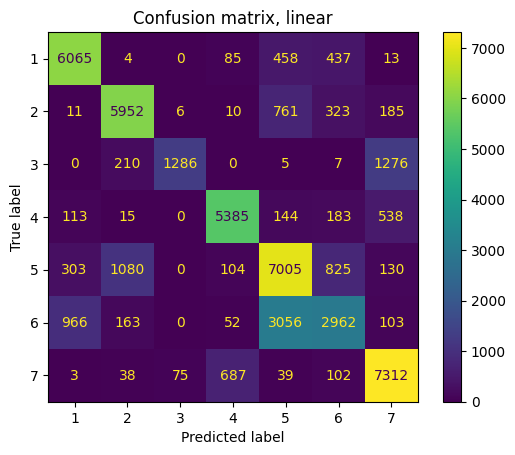

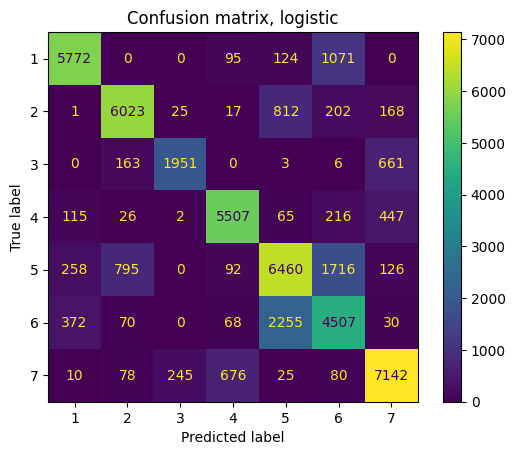

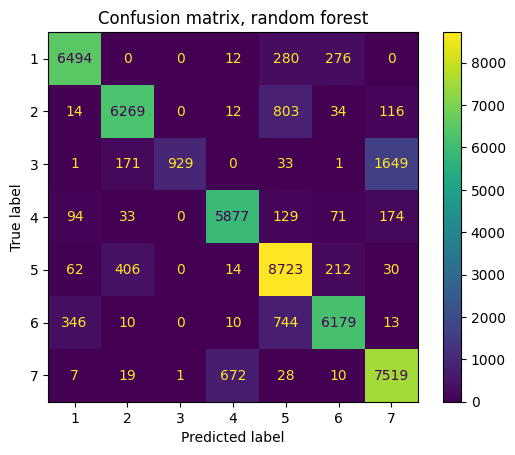

In [223]:
#display(df_new)
#display(df_class)

all_labels = np.unique(class_wise["All_true"])

conf_matrix_linear = confusion_matrix(class_wise["All_true"], class_wise["preds_linear"])

cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix_linear, display_labels = all_labels)
cm_display.plot()
plt.title("Confusion matrix, linear")
plt.show()

conf_matrix_log = confusion_matrix(class_wise["All_true"], class_wise["preds_logistic"])

cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix_log, display_labels = all_labels)
cm_display.plot()
plt.title("Confusion matrix, logistic")
plt.show()


conf_matrix_rf = confusion_matrix(class_wise["All_true"], class_wise["preds_rf"])

cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix_rf, display_labels = all_labels)
cm_display.plot()
plt.title("Confusion matrix, random forest")
plt.show()



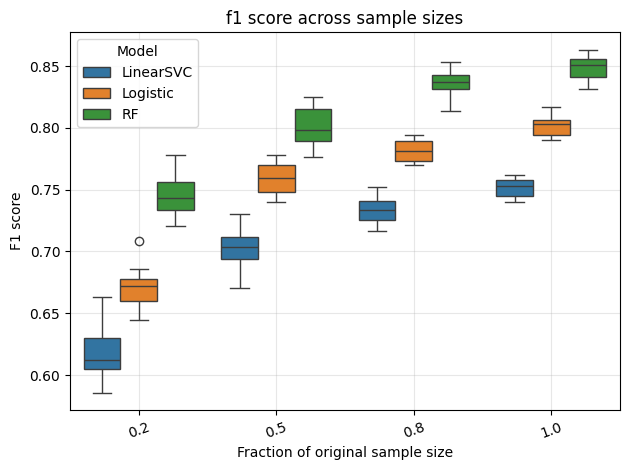

In [224]:
sns.boxplot(
    data=df_new,
    x="Sample size",
    y="f1 score",
    hue = "Model"
)
plt.title("f1 score across sample sizes")
plt.xlabel("Fraction of original sample size")
plt.ylabel("F1 score")
plt.tick_params(axis="x", rotation=20)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

[1, 2, 3, 4, 5, 6, 7]
[np.int64(1190), np.int64(1190), np.int64(487), np.int64(1082), np.int64(1567), np.int64(1219), np.int64(1345)]
linear
              precision    recall  f1-score   support

           1       0.81      0.86      0.84      7062
           2       0.80      0.82      0.81      7248
           3       0.94      0.47      0.63      2784
           4       0.85      0.84      0.85      6378
           5       0.61      0.74      0.67      9447
           6       0.61      0.41      0.49      7302
           7       0.76      0.89      0.82      8256

    accuracy                           0.74     48477
   macro avg       0.77      0.72      0.73     48477
weighted avg       0.75      0.74      0.73     48477

logistic
              precision    recall  f1-score   support

           1       0.88      0.81      0.85      7062
           2       0.84      0.83      0.83      7248
           3       0.88      0.70      0.78      2784
           4       0.85      0.86   

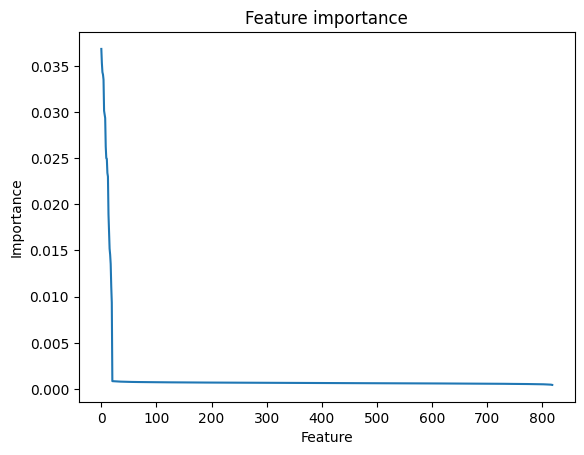

In [221]:
#Find out more about the data
print(existing_labels)
for_each = []
for i in existing_labels:
    for_each.append(np.count_nonzero(labels == i))
print(for_each)

print("linear")
print(classification_report(class_wise["All_true"], class_wise["preds_linear"]))

print("logistic")
print(classification_report(class_wise["All_true"], class_wise["preds_logistic"]))

print("rf")
print(classification_report(class_wise["All_true"], class_wise["preds_rf"]))


rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X, labels)

importance = rf.feature_importances_

sorted_importance = np.sort(importance)[::-1]

plt.plot(sorted_importance)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature importance")
plt.show()

#Steep dropoff -> A few features that matter a lot





In [225]:
#Minimum disruption
results_disruption = {
    "Sample size": [],
    "Model": [],
    "f1 score": [],
    "Fold": []
}

class_disruption = {
    "All_true": [],
    "preds_linear": [], 
    "preds_logistic": [],
    "preds_rf": []
}

for sample_size in sample_sizes:
    print(f"sample size: {sample_size}")
    results_disruption, class_disruption = training(14, results_disruption, params_tuned, x_eval, y_eval, sample_size, True, 3, 3, class_disruption) 


df_disruption = pd.DataFrame(data=results_disruption)


sample size: 0.2
(6464, 819)
6464
(1292, 819)
1292
Linear, f1 score = 0.572318556157201
Logistic,  f1 =  0.6062541183527319
RF, f1 = 0.7617246557514125
Linear, f1 score = 0.6049369957499785
Logistic,  f1 =  0.6370152208234795
RF, f1 = 0.6883152909589575
Linear, f1 score = 0.5845163078264407
Logistic,  f1 =  0.6233614686279599
RF, f1 = 0.7193154070234309
Linear, f1 score = 0.6178202573762065
Logistic,  f1 =  0.616048098402446
RF, f1 = 0.7583456196308945
Linear, f1 score = 0.6224125127156581
Logistic,  f1 =  0.6579394714798761
RF, f1 = 0.7237417793559622
Linear, f1 score = 0.5667488549289427
Logistic,  f1 =  0.668634223254693
RF, f1 = 0.7219598712816682
Linear, f1 score = 0.5636099415774416
Logistic,  f1 =  0.6093415036619904
RF, f1 = 0.6842207696959657
Linear, f1 score = 0.6192322685135905
Logistic,  f1 =  0.6340482877461021
RF, f1 = 0.7270564914669256
Linear, f1 score = 0.6125448455263254
Logistic,  f1 =  0.6709709207300323
RF, f1 = 0.7340836103647849
sample size: 0.5
(6464, 819)
6464


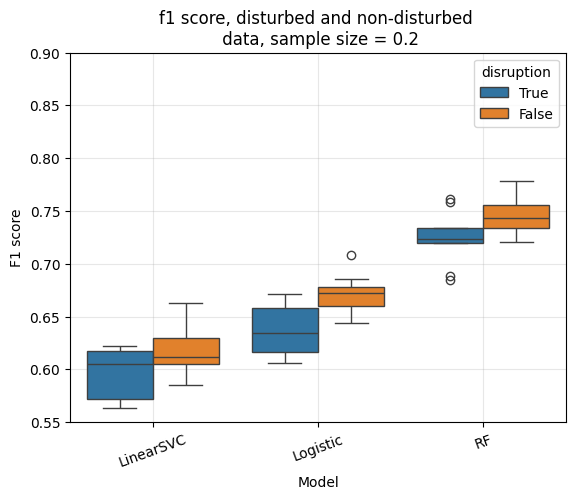

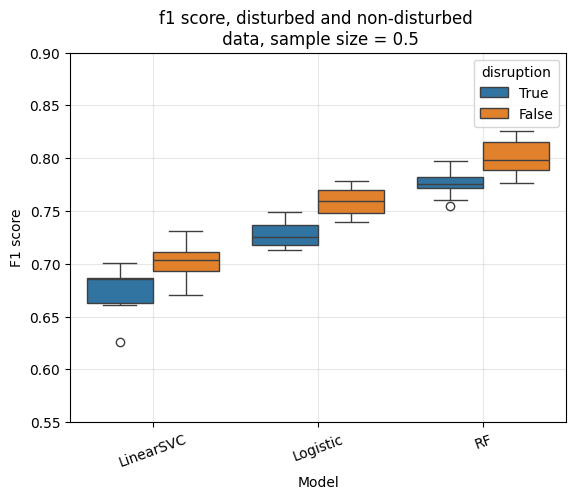

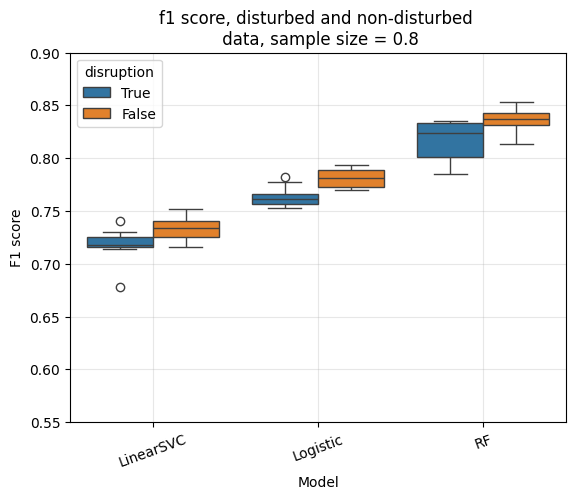

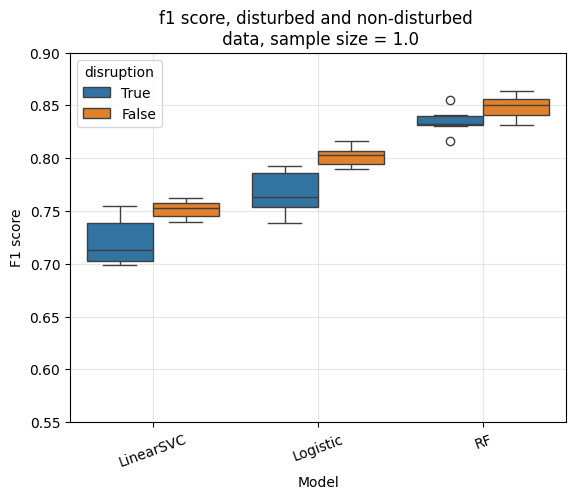

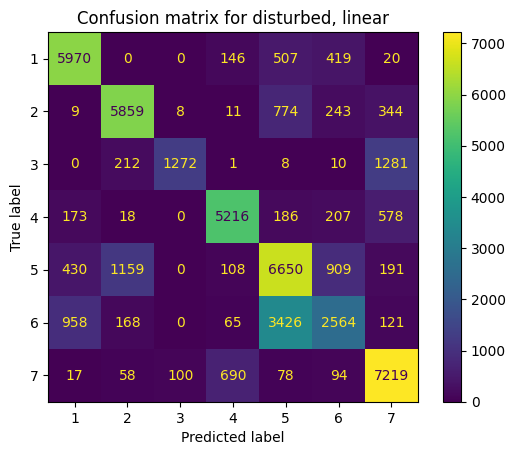

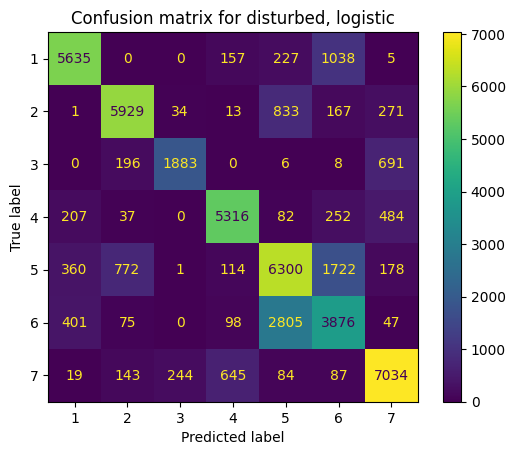

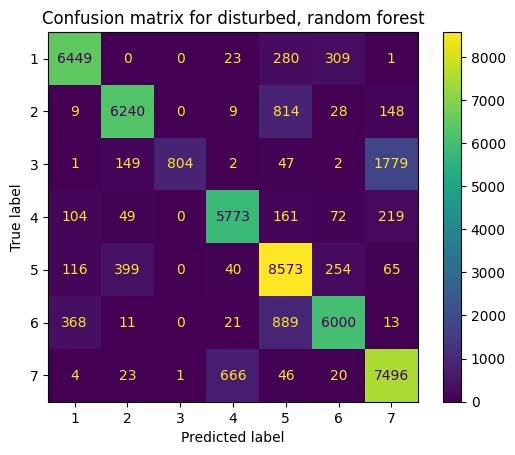

In [245]:
rows = len(df_disruption)

df_disruption["disruption"] = ["True"]*rows
df_new["disruption"] = ["False"]*rows
df_combined = pd.concat([df_disruption, df_new])

#fig, ax = plt.subplots(4, 1, sharey=True, figsize = (15,40))
#axes = ax.flatten()

for i, s in enumerate(sample_sizes):
    sns.boxplot(
        data=df_combined[df_combined["Sample size"] == s],
        x="Model",
        y="f1 score",
        hue = "disruption",
    )
    plt.title(f"f1 score, disturbed and non-disturbed \n data, sample size = {s}")
    plt.ylim(0.55, 0.9)
    plt.xlabel("Model")
    plt.ylabel("F1 score")
    plt.tick_params(axis="x", rotation=20)
    plt.grid(True, alpha=0.3)


    plt.show()




conf_matrix_linear_dis = confusion_matrix(class_disruption["All_true"], class_disruption["preds_linear"])

cm_display_dis = ConfusionMatrixDisplay(confusion_matrix = conf_matrix_linear_dis, display_labels = all_labels)
cm_display_dis.plot()
plt.title("Confusion matrix for disturbed, linear")
plt.show()

conf_matrix_log_dis = confusion_matrix(class_disruption["All_true"], class_disruption["preds_logistic"])

cm_display_log_dis = ConfusionMatrixDisplay(confusion_matrix = conf_matrix_log_dis, display_labels = all_labels)
cm_display_log_dis.plot()
plt.title("Confusion matrix for disturbed, logistic")
plt.show()


conf_matrix_rf_dis = confusion_matrix(class_disruption["All_true"], class_disruption["preds_rf"])

cm_display_rf_dis = ConfusionMatrixDisplay(confusion_matrix = conf_matrix_rf_dis, display_labels = all_labels)
cm_display_rf_dis.plot()
plt.title("Confusion matrix for disturbed, random forest")
plt.show()



In [78]:
display(df)

,Sample size,Model,Seed,Best parameters,f1 score,disruption
0,0.2,LinearSVC,42,"{'pca': PCA(n_components=20), 'Classifier__C': 0.3359818286283781}",0.676936,False
1,0.2,Logistic,42,"{'pca': PCA(n_components=10), 'Classifier__C': 0.1623776739188721}",0.690105,False
2,0.2,RF,42,"{'Classifier__n_estimators': 100, 'Classifier__max_depth': 10}",0.861702,False
3,0.2,LinearSVC,67,"{'pca': PCA(n_components=50), 'Classifier__C': 54.555947811685144}",0.685943,False
4,0.2,Logistic,67,"{'pca': PCA(n_components=10), 'Classifier__C': 1000.0}",0.714992,False
5,0.2,RF,67,"{'Classifier__n_estimators': 100, 'Classifier__max_depth': 20}",0.800464,False
6,0.2,LinearSVC,1,"{'pca': PCA(n_components=50), 'Classifier__C': 6.158482110660261}",0.677706,False
7,0.2,Logistic,1,"{'pca': PCA(n_components=10), 'Classifier__C': 1000.0}",0.704727,False
8,0.2,RF,1,"{'Classifier__n_estimators': 50, 'Classifier__max_depth': None}",0.785873,False
9,0.5,LinearSVC,42,"{'pca': PCA(n_components=100), 'Classifier__C': 26.366508987303554}",0.728835,False


In [280]:
#Find mislabeling: 



mislabled = {
    "index": [],
    "label (mislabeled)": [],
    "predicted label": []
}
def find_mislabeled(random_seed, X, y, parameters):

    mislabeled = []

    pipe_rf = Pipeline([  
            ('Classifier', RandomForestClassifier(random_state=random_seed, n_jobs = -1, n_estimators= parameters[2]['Classifier__n_estimators'], max_depth= parameters[2]['Classifier__max_depth']))
        ])

    kfold = KFold(n_splits = 10, shuffle = True, random_state= random_seed)

    wrong = np.zeros(len(y))

    mislabled_at_any_point = np.zeros((11, len(y)))
    print("hi")

    for j, (train_idx, val_idx) in enumerate(kfold.split(X,y)):
        #print("split")
        pipe_rf.fit(X[train_idx], y[train_idx])
        prediction = pipe_rf.predict(X[val_idx])
        #print(f"prediction is {prediction} and y is {y} and y_val idx is {y[val_idx]}")
        #print(f"len prediction is {len(prediction)} and len y is {len(y[val_idx])}, wrong is {len(wrong)}")

        for i, indx in enumerate(val_idx): 
            if prediction[i] != y[indx]:
                wrong[indx] += 1
                mislabled_at_any_point[j][indx] += 1
                mislabled_at_any_point[11][indx] += 1
            if wrong[indx] >= 2:
                print("HUHIU")

    mislabeled_at_any_point_df = pd.DataFrame(data = mislabled_at_any_point)
    display(mislabeled_at_any_point_df)
    for i in range(len(wrong)-1, 0, -1):
        if wrong[i] >= 2:
            print(f"wrong i is {wrong[i]}")
        if wrong[i] >= 3:
            X.pop(i)
            mislabeled.append(i)
    

    return X, mislabeled

X_without, mislabled_data = find_mislabeled(random_seed, x_var, labels, params_tuned)   

df_mislabeled = pd.DataFrame(data=mislabled_data)
display(df_mislabeled)

#mislabel one
labels_new = labels.copy()
labels_new[-1] = 4
X_with_one_mislabeled, mislabled_data_with_one_mislabeled = find_mislabeled(random_seed, x_var, labels_new, params_tuned)  
df_mislabeled_2 = pd.DataFrame(data=mislabled_data_with_one_mislabeled)
display(df_mislabeled_2)



hi


IndexError: index 11 is out of bounds for axis 0 with size 11

In [ ]:
def evaluation(X,y,models, n_repeats, n_splits, seed):
    outer_results = []

    for repeat in range(n_repeats):
        folds = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True, 
            random_state = seed+repeat
        )

        fold_score = []
        for train_idx, test_idx in folds.split(X,y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model = models(seed+repeat)

            model.fit(X_train, y_train)

            preds = model.predict(X_test)

            fold_scores.append(f1_scores(y_test, preds, average="macro"))
        
        outer_results.append(np.mean(fold_scores))
    return outer_results

def logistic(seed):
    return LogisticRegression(max_iter=5000, solver="saga", random_state=seed)

def svm(seed):
    return LinearSVC(random_state=seed)

def rf(seed):
    return RandomForestClassifier(random_state=seed, n_estimators=200)

results = {
    "logistic": [],
    "SVM": [],
    "RF": []
}

for i in range(10):
    results["Logistic"].append(
        evaluation(X,labels, logistic, seed=i)[0]
    )

    results["SVM"].append(
        evaluation(X, labels, svm, seed=i)[0]
    )

    results["RF"].append(
        evaluation(X, labels, rf, seed=i)[0]
    )